In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
!pip install seaborn

import seaborn as sns

# Load the data
df = pd.read_csv("readmissions_raw.csv")

# First look
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Shape: (18330, 12)

Columns: ['Facility Name', 'Facility ID', 'State', 'Measure Name', 'Number of Discharges', 'Footnote', 'Excess Readmission Ratio', 'Predicted Readmission Rate', 'Expected Readmission Rate', 'Number of Readmissions', 'Start Date', 'End Date']

First 5 rows:


,Facility Name,Facility ID,State,Measure Name,Number of Discharges,Footnote,Excess Readmission Ratio,Predicted Readmission Rate,Expected Readmission Rate,Number of Readmissions,Start Date,End Date
0,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-HIP-KNEE-HRRP,NaN,NaN,0.9875,4.5734,4.6311,Too Few to Report,07/01/2021,06/30/2024
1,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-CABG-HRRP,137.0,NaN,0.9531,10.3960,10.9078,13,07/01/2021,06/30/2024
2,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-AMI-HRRP,273.0,NaN,0.9370,13.2998,14.1948,33,07/01/2021,06/30/2024
3,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-COPD-HRRP,122.0,NaN,0.9823,16.6384,16.9389,19,07/01/2021,06/30/2024
4,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-PN-HRRP,507.0,NaN,0.9871,15.7529,15.9591,79,07/01/2021,06/30/2024


In [4]:
import pandas as pd

df = pd.read_csv("readmissions_raw.csv")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

Shape: (18330, 12)

Columns: ['Facility Name', 'Facility ID', 'State', 'Measure Name', 'Number of Discharges', 'Footnote', 'Excess Readmission Ratio', 'Predicted Readmission Rate', 'Expected Readmission Rate', 'Number of Readmissions', 'Start Date', 'End Date']


In [5]:
# How many hospitals and diagnoses do we have?
print("Total rows:", len(df))
print("Total unique hospitals:", df['Facility Name'].nunique())
print("Total unique states:", df['State'].nunique())
print("Diagnoses we're tracking:")
for measure in df['Measure Name'].unique():
    print(" -", measure)

Total rows: 18330
Total unique hospitals: 2995
Total unique states: 51
Diagnoses we're tracking:
 - READM-30-HIP-KNEE-HRRP
 - READM-30-CABG-HRRP
 - READM-30-AMI-HRRP
 - READM-30-COPD-HRRP
 - READM-30-PN-HRRP
 - READM-30-HF-HRRP


In [6]:
# Create a readable name mapping
measure_names = {
    'READM-30-HIP-KNEE-HRRP': 'Hip & Knee Replacement',
    'READM-30-CABG-HRRP': 'Heart Bypass Surgery',
    'READM-30-AMI-HRRP': 'Heart Attack',
    'READM-30-COPD-HRRP': 'COPD',
    'READM-30-PN-HRRP': 'Pneumonia',
    'READM-30-HF-HRRP': 'Heart Failure'
}

# Apply the mapping
df['Condition'] = df['Measure Name'].map(measure_names)

# Check it worked
print(df[['Measure Name', 'Condition']].drop_duplicates())

             Measure Name               Condition
0  READM-30-HIP-KNEE-HRRP  Hip & Knee Replacement
1      READM-30-CABG-HRRP    Heart Bypass Surgery
2       READM-30-AMI-HRRP            Heart Attack
3      READM-30-COPD-HRRP                    COPD
4        READM-30-PN-HRRP               Pneumonia
5        READM-30-HF-HRRP           Heart Failure


In [8]:
# Start fresh from original df
df_clean = df.copy()

# Convert all numeric columns -- force any non-numeric to NaN
df_clean['Excess Readmission Ratio'] = pd.to_numeric(df_clean['Excess Readmission Ratio'], errors='coerce')
df_clean['Predicted Readmission Rate'] = pd.to_numeric(df_clean['Predicted Readmission Rate'], errors='coerce')
df_clean['Expected Readmission Rate'] = pd.to_numeric(df_clean['Expected Readmission Rate'], errors='coerce')
df_clean['Number of Readmissions'] = pd.to_numeric(df_clean['Number of Readmissions'], errors='coerce')
df_clean['Number of Discharges'] = pd.to_numeric(df_clean['Number of Discharges'], errors='coerce')

# Now drop any rows where key columns are NaN
df_clean = df_clean.dropna(subset=[
    'Excess Readmission Ratio',
    'Number of Readmissions',
    'Predicted Readmission Rate',
    'Number of Discharges'
]).copy()

print("Before cleaning:", len(df), "rows")
print("After cleaning:", len(df_clean), "rows")
print("Rows removed:", len(df) - len(df_clean))
print("\nData types now:")
print(df_clean[['Excess Readmission Ratio', 'Number of Readmissions']].dtypes)

Before cleaning: 18330 rows
After cleaning: 8037 rows
Rows removed: 10293

Data types now:
Excess Readmission Ratio    float64
Number of Readmissions      float64
dtype: object


In [9]:
# Save cleaned data for Power BI later
df_clean.to_csv("cleaned_readmissions.csv", index=False)
print("Saved! Shape:", df_clean.shape)
print("\nQuick summary of key columns:")
print(df_clean[['Excess Readmission Ratio', 
                 'Predicted Readmission Rate',
                 'Number of Readmissions',
                 'Number of Discharges']].describe())

Saved! Shape: (8037, 13)

Quick summary of key columns:
       Excess Readmission Ratio  Predicted Readmission Rate  \
count               8037.000000                 8037.000000   
mean                   1.009088                   16.569124   
std                    0.078521                    3.702850   
min                    0.469800                    1.908000   
25%                    0.964000                   14.439400   
50%                    1.006000                   17.032700   
75%                    1.050900                   19.101400   
max                    1.582700                   28.164300   

       Number of Readmissions  Number of Discharges  
count             8037.000000           8037.000000  
mean                48.750653            290.645390  
std                 49.758206            270.506342  
min                 11.000000             27.000000  
25%                 19.000000            122.000000  
50%                 31.000000            203.000000 

In [10]:
# Which conditions have the highest average readmission ratio?
print("Average Excess Readmission Ratio by Condition:")
condition_avg = df_clean.groupby('Condition')['Excess Readmission Ratio'].mean().sort_values(ascending=False)
print(condition_avg.round(3))

print("\n Which states have the highest average readmission ratio?")
state_avg = df_clean.groupby('State')['Excess Readmission Ratio'].mean().sort_values(ascending=False)
print("Top 10 worst states:")
print(state_avg.head(10).round(3))
print("\nTop 10 best states:")
print(state_avg.tail(10).round(3))

Average Excess Readmission Ratio by Condition:
Condition
Hip & Knee Replacement    1.036
Heart Bypass Surgery      1.029
COPD                      1.011
Heart Attack              1.010
Pneumonia                 1.007
Heart Failure             1.004
Name: Excess Readmission Ratio, dtype: float64

 Which states have the highest average readmission ratio?
Top 10 worst states:
State
MA    1.044
NJ    1.031
FL    1.028
MS    1.027
IL    1.027
LA    1.025
AL    1.024
WV    1.024
NV    1.023
CA    1.019
Name: Excess Readmission Ratio, dtype: float64

Top 10 best states:
State
DE    0.969
KS    0.963
WY    0.962
SD    0.962
ME    0.956
ND    0.954
OR    0.950
MT    0.946
UT    0.937
ID    0.914
Name: Excess Readmission Ratio, dtype: float64


In [11]:
# Top 20 worst performing hospitals
worst_hospitals = df_clean.groupby(['Facility Name', 'State']).agg(
    Avg_Excess_Ratio=('Excess Readmission Ratio', 'mean'),
    Total_Readmissions=('Number of Readmissions', 'sum'),
    Total_Discharges=('Number of Discharges', 'sum')
).reset_index()

# Calculate readmission rate
worst_hospitals['Readmission_Rate_%'] = (
    worst_hospitals['Total_Readmissions'] / 
    worst_hospitals['Total_Discharges'] * 100
).round(2)

# Sort by worst ratio
worst_hospitals = worst_hospitals.sort_values('Avg_Excess_Ratio', ascending=False)

print("Top 10 Worst Performing Hospitals:")
print(worst_hospitals.head(10).to_string(index=False))

print("\nTop 10 Best Performing Hospitals:")
print(worst_hospitals.tail(10).to_string(index=False))

Top 10 Worst Performing Hospitals:
                                     Facility Name State  Avg_Excess_Ratio  Total_Readmissions  Total_Discharges  Readmission_Rate_%
                     SURGICAL INSTITUTE OF READING    PA           1.30970                18.0             241.0                7.47
      CHRISTUS CENTRAL LOUISIANA SURGICAL HOSPITAL    LA           1.30370                16.0             177.0                9.04
                                 OROVILLE HOSPITAL    CA           1.28250               384.0            1268.0               30.28
                               CASTLEVIEW HOSPITAL    UT           1.27060                11.0             182.0                6.04
             MIDWEST ORTHOPEDIC SPECIALTY HOSPITAL    WI           1.26280                17.0             245.0                6.94
ARIZONA ORTHOPEDIC AND SURGICAL SPECIALTY HOSPITAL    AZ           1.25910                16.0             261.0                6.13
                               WIN

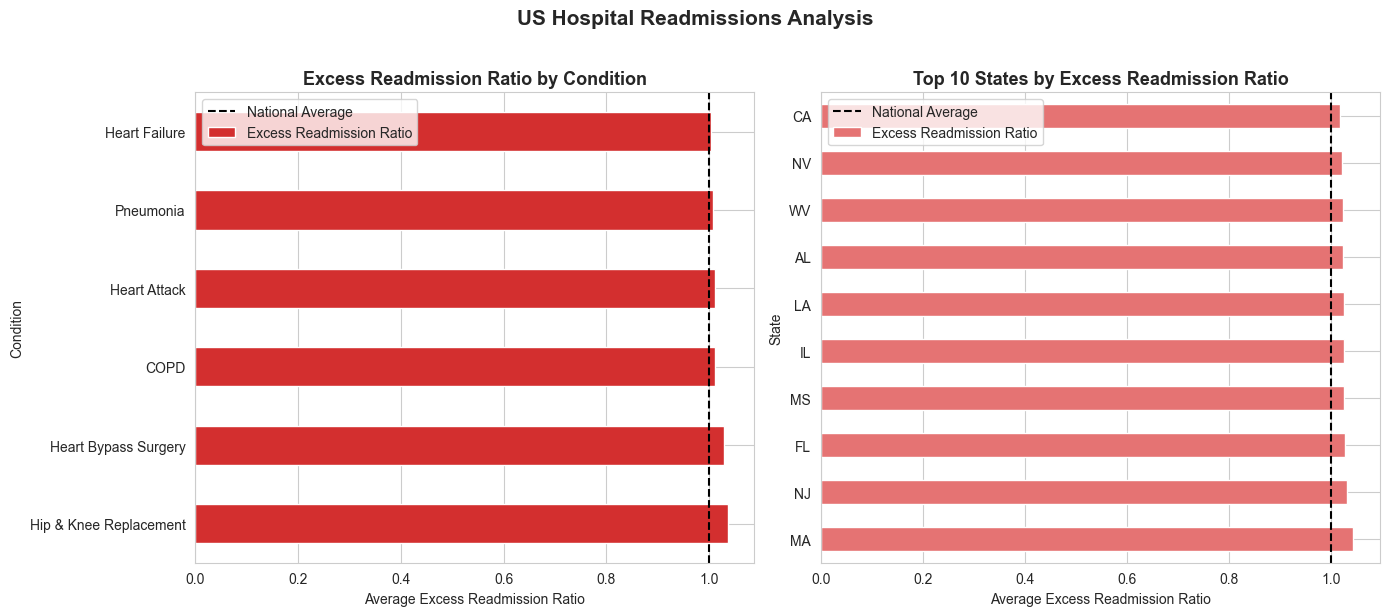

Chart saved!


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1 -- Average ratio by condition
condition_avg.plot(
    kind='barh', 
    ax=axes[0],
    color=['#d32f2f' if x > 1 else '#388e3c' for x in condition_avg.values]
)
axes[0].set_title('Excess Readmission Ratio by Condition', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Average Excess Readmission Ratio')
axes[0].axvline(x=1, color='black', linestyle='--', linewidth=1.5, label='National Average')
axes[0].legend()

# Chart 2 -- Top 10 worst states
top_states = state_avg.head(10)
top_states.plot(
    kind='barh',
    ax=axes[1],
    color='#e57373'
)
axes[1].set_title('Top 10 States by Excess Readmission Ratio', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Average Excess Readmission Ratio')
axes[1].axvline(x=1, color='black', linestyle='--', linewidth=1.5, label='National Average')
axes[1].legend()

plt.suptitle('US Hospital Readmissions Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('readmissions_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [13]:
import sqlite3

# Create a SQLite database
conn = sqlite3.connect('healthcare.db')

# Load clean data into it
df_clean.to_sql('readmissions', conn, if_exists='replace', index=False)

print("Database created!")
print("Table 'readmissions' loaded with", len(df_clean), "rows")

conn.close()

Database created!
Table 'readmissions' loaded with 8037 rows


In [ ]:
# Create Tableau-ready export
tableau_df = df_clean[[
    'Facility Name',
    'Facility ID', 
    'State',
    'Condition',
    'Excess Readmission Ratio',
    'Predicted Readmission Rate',
    'Expected Readmission Rate',
    'Number of Readmissions',
    'Number of Discharges'
]].copy()

# Add hospital size category
tableau_df['Hospital Size'] = pd.cut(
    tableau_df['Number of Discharges'],
    bins=[0, 100, 300, 600, float('inf')],
    labels=['Small', 'Medium', 'Large', 'Very Large']
)

# Add performance category
tableau_df['Performance'] = tableau_df['Excess Readmission Ratio'].apply(
    lambda x: 'Better Than Average' if x < 0.98 
    else 'Worse Than Average' if x > 1.02 
    else 'Average'
)

# Save
tableau_df.to_csv('tableau_readmissions.csv', index=False)
print("Tableau file ready!")
print("Shape:", tableau_df.shape)
print("\nPerformance breakdown:")
print(tableau_df['Performance'].value_counts())
print("\nHospital Size breakdown:")
print(tableau_df[' Hospital Size'].value_counts())

Tableau file ready!
Shape: (8037, 11)

Performance breakdown:
Performance
Worse Than Average     3349
Better Than Average    2701
Average                1987
Name: count, dtype: int64

Hospital Size breakdown:
Hospital Size
Medium        4070
Large         1784
Small         1354
Very Large     829
Name: count, dtype: int64
